newton raphson method

Iteration	Root Approximation	Error
1	0.838218		1.617816e-01
2	0.824242		1.397654e-02
3	0.824132		1.095492e-04


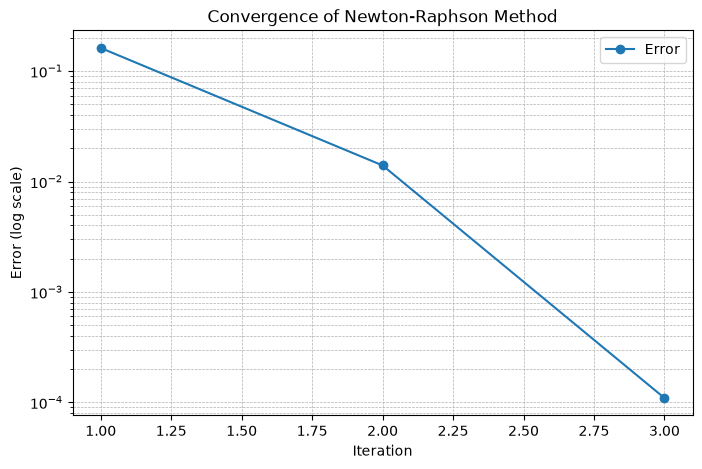

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def newton_raphson(f, df, x0, tol=0.5e-6, max_iter=100):
    """
    Implements the Newton-Raphson method to find the root of f(x) = 0.

    Parameters:
    f (function): The function for which the root is to be found.
    df (function): The derivative of the function.
    x0 (float): Initial guess.
    tol (float): Tolerance for the stopping criterion.
    max_iter (int): Maximum number of iterations.

    Returns:
    root (float): The approximated root.
    error_table (list): A table of iterations, root approximations, and errors.
    """
    
    error_table = []

    for iteration in range(1, max_iter + 1):
        # Compute the next approximation
        fx = f(x0)
        dfx = df(x0)

        if dfx == 0:
            raise ZeroDivisionError("Derivative is zero. Method fails.")

        x1 = x0 - fx / dfx  # Newton-Raphson formula
        error = abs(x1 - x0)

        # Store iteration details
        error_table.append((iteration, x1, error))

        # Check for convergence
        if error < tol or abs(f(x1)) < tol:
            return x1, error_table

        x0 = x1

    raise RuntimeError("Maximum iterations exceeded without convergence.")


# Define the function and its derivative
def f(x):
    #return x**2 - 4
    return x**2 - np.cos(x)


def df(x):
    #return 2 * x
    return 2*x + np.sin(x)


# Initial guess
x0 = 1

# Find the root
root, error_table = newton_raphson(f, df, x0)

# Print the error table
print("Iteration\tRoot Approximation\tError")
for iteration, x1, error in error_table:
    print(f"{iteration}\t{x1:.6f}\t\t{error:.6e}")


# Plot the convergence
iterations = [row[0] for row in error_table]
errors = [row[2] for row in error_table]

plt.figure(figsize=(8, 5))
plt.plot(iterations, errors, marker='o', label='Error')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Error (log scale)')
plt.title('Convergence of Newton-Raphson Method')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

Iteration	X		Y		Error
1		2.443516	1.075312	1.025551e+00
2		2.221035	1.106178	2.246117e-01
3		2.208679	1.109837	1.288634e-02
4		2.208638	1.109850	4.309178e-05
5		2.208638	1.109850	4.818423e-10

Root: [2.20863823 1.10985014]


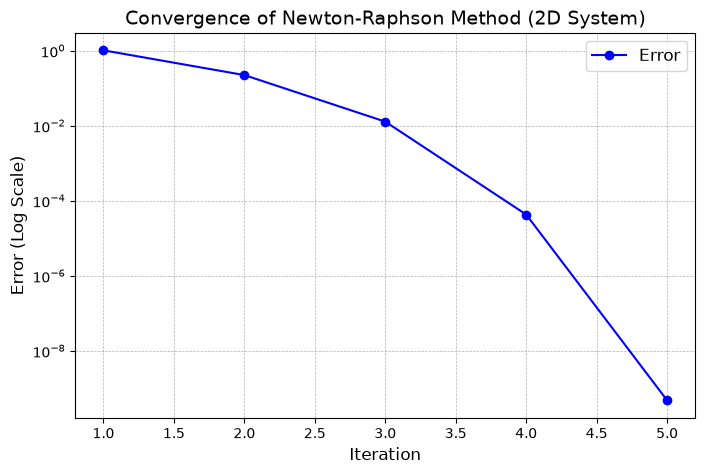

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def newton_raphson_2d(F, J, x0, tol=0.5e-6, max_iter=100):
    """
    Newton-Raphson method for a system of two nonlinear equations.

    Parameters:
    F (function): A function that returns the vector of equations.
    J (function): A function that returns the Jacobian matrix.
    x0 (array-like): Initial guess [x, y].
    tol (float): Tolerance for stopping criterion.
    max_iter (int): Maximum number of iterations.

    Returns:
    x (numpy array): Approximated root [x, y].
    error_table (list): Error and root approximations at each iteration.
    """
    x = np.array(x0, dtype=float)
    error_table = []

    for i in range(max_iter):
        F_val = np.array(F(x))
        J_val = np.array(J(x))

        # Solve J * delta = -F
        delta = np.linalg.solve(J_val, -F_val)
        x_next = x + delta  # NR formula
        error = np.linalg.norm(delta)

        error_table.append((i + 1, x_next[0], x_next[1], error))

        # Check for convergence
        if error < tol:
            return x_next, error_table

        x = x_next

    raise RuntimeError("Maximum iterations exceeded without convergence.")


# Define the system of equations
def F_example(x):
    return [
        #x[0]**2 + x[1]**2 - 4,      # f1(x, y)=x^2+y^2-4
        #np.exp(x[0]) + x[1] - 1     # f2(x, y)=e^x+y-1
        x[0]**2+x[1]**2-x[1]-5,
        -np.exp(-x[0])+x[1]-1
    ]


# Define the Jacobian
def J_example(x):
    return [
        #[2 * x[0], 2 * x[1]],       # Partial derivatives of f1
        #[np.exp(x[0]), 1]           # Partial derivatives of f2
        [2*x[0],2*x[1]-1],
        [np.exp(-x[0]), 1]
    ]


# Initial guess for the system of equations
x0_example = [2,2]

# Solve the system using the Newton-Raphson method
root_2d, error_table_2d = newton_raphson_2d(F_example, J_example, x0_example)

# Print the results
print("Iteration\tX\t\tY\t\tError")
for row in error_table_2d:
    print(f"{row[0]}\t\t{row[1]:.6f}\t{row[2]:.6f}\t{row[3]:.6e}")

print(f"\nRoot: {root_2d}")

# Plot convergence
iterations = [row[0] for row in error_table_2d]
errors = [row[3] for row in error_table_2d]

plt.figure(figsize=(8, 5))
plt.semilogy(iterations, errors, marker='o', linestyle='-', color='b', label='Error')
plt.title("Convergence of Newton-Raphson Method (2D System)", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Error (Log Scale)", fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)
plt.show()f